# FedAvg under Pathological Label Skew — MNIST

This notebook studies **FedAvg under a severe non-IID label distribution** created by
pathological sharding.

The reusable FedAvg implementation lives under `src/`; this notebook changes only the
**client data partition**.

**Research question.** How does FedAvg behave when clients optimize strongly different local
label distributions, and how does increasing local training \(E\) affect that behavior?

**Controlled variables**

- same MNIST preprocessing,
- same 5-client setup,
- same `SimpleMLP`,
- same SGD learning rate and batch size,
- same test set,
- same saved initial weights \(w_0\),
- full participation (\(C=1\)).

The experimental change is the client partition: IID \(\rightarrow\) pathological label skew.

## 1. Setup

In [2]:
from pathlib import Path
import os
import sys

# Remove stale Kaggle repo paths from previous setup
sys.path = [
    p for p in sys.path
    if "/kaggle/working/federated-learning-under-heterogeneity" not in str(p)
]

# VS Code should be opened at the repository root
REPO_ROOT = Path.cwd().resolve()

# If Jupyter starts inside notebooks/, move one level up
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

# Verify that this really is our repository
if not (REPO_ROOT / "src").is_dir():
    raise RuntimeError(
        f"Current directory is not the repo root:\n{REPO_ROOT}\n\n"
        "Open federated-learning-under-heterogeneity as the folder in VS Code."
    )

# Reset working directory
os.chdir(REPO_ROOT)

# Make src importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("Repo root :", REPO_ROOT)
print("Working dir:", Path.cwd())
print("Python     :", sys.executable)

Repo root : D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity
Working dir: D:\HKU\New folder\federated-learning-under-heterogeneity-final\federated-learning-under-heterogeneity
Python     : d:\Anaconda\python.exe


In [11]:
import copy
import random
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from src.models import SimpleMLP
from src.data import (
    partition_dirichlet,
    create_client_loaders,
    client_label_counts,
)
from src.training import (
    evaluate,
    client_update,
    federated_train,
)
from src.metrics import model_distance

In [12]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_best_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def load_mnist(root):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ])
    train_ds = datasets.MNIST(root=root, train=True, download=True, transform=transform)
    test_ds = datasets.MNIST(root=root, train=False, download=True, transform=transform)
    return train_ds, test_ds


def verify_partition(client_indices, dataset_size: int):
    flat = [
        int(idx)
        for indices in client_indices.values()
        for idx in indices
    ]
    assert len(flat) == dataset_size, "Some examples were dropped or duplicated."
    assert len(set(flat)) == dataset_size, "Client partitions overlap."
    assert min(flat) >= 0 and max(flat) < dataset_size
    return {
        "total_assigned": len(flat),
        "unique_assigned": len(set(flat)),
    }

In [13]:
@dataclass(frozen=True)
class ExperimentConfig:
    seed: int = 42
    num_clients: int = 5
    shards_per_client: int = 2
    batch_size: int = 64
    learning_rate: float = 0.01
    full_num_rounds: int = 20
    local_epoch_values: tuple = (1, 5, 10)
    datasets_dir: str = "datasets"
    iid_results_dir: str = "results/iid_baseline"
    results_dir: str = "results/dirichlet_noniid"


CFG = ExperimentConfig()
device = get_best_device()
print(f"Using device: {device}")

Using device: cpu


### Implementation map

This notebook uses the same reusable components as the IID baseline:

- `src/models.py` — model definition
- `src/data.py` — shard partition and loaders
- `src/aggregate.py` — FedAvg aggregation
- `src/training.py` — client update and federated loop
- `src/metrics.py` — model-distance diagnostic

No source files, Git commands, authentication tokens, or package-generation cells belong in
this experiment notebook.

## 2. Load MNIST

In [14]:
set_seed(CFG.seed)

train_ds, test_ds = load_mnist(REPO_ROOT / CFG.datasets_dir)
test_loader = DataLoader(
    test_ds,
    batch_size=CFG.batch_size,
    shuffle=False,
)

print(f"Training examples: {len(train_ds)}")
print(f"Test examples: {len(test_ds)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 7.04MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 182kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.45MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.99MB/s]


Training examples: 60000
Test examples: 10000


## 3. Create the pathological shard partition

The training examples are sorted by label and split into

\[
K \times s = 5 \times 2 = 10
\]

shards, where \(s=2\) shards are assigned to each client. With 60,000 training examples,
each shard contains 6,000 examples and every client receives 12,000 examples.

Because the data are sorted by label before sharding, each client's local distribution is
concentrated on a small number of digits.

In [15]:
client_indices = partition_dirichlet(
    train_ds,
    num_clients=CFG.num_clients,
    seed=CFG.seed,
    alpha=0.1,
)

partition_check = verify_partition(client_indices, len(train_ds))
client_loaders = create_client_loaders(
    train_ds,
    client_indices,
    batch_size=CFG.batch_size,
)

print(partition_check)
print({client_id: len(indices) for client_id, indices in client_indices.items()})

{'total_assigned': 60000, 'unique_assigned': 60000}
{0: 8505, 1: 8904, 2: 13325, 3: 21164, 4: 8102}


## 4. Inspect client label distributions

In [16]:
distribution_df = client_label_counts(train_ds, client_indices)
distribution_df

,client,samples,digit_0,digit_1,digit_2,digit_3,digit_4,digit_5,digit_6,digit_7,digit_8,digit_9
0,0,8505,7,0,0,5526,16,0,15,756,2182,3
1,1,8904,0,91,627,11,2027,0,2306,0,3668,174
2,2,13325,79,0,5329,44,1625,0,3450,1,0,2797
3,3,21164,1721,6650,0,0,1950,5417,69,5357,0,0
4,4,8102,4116,1,2,550,224,4,78,151,1,2975


In [17]:
digit_columns = [f"digit_{d}" for d in range(10)]
proportions = (
    distribution_df[digit_columns]
    .div(distribution_df["samples"], axis=0)
)

top2_share = np.sort(proportions.to_numpy(), axis=1)[:, -2:].sum(axis=1)

concentration_df = pd.DataFrame({
    "client": distribution_df["client"],
    "top_2_label_share": top2_share,
})
concentration_df

,client,top_2_label_share
0,0,0.906290
1,1,0.670934
2,2,0.658837
3,3,0.570166
4,4,0.875216


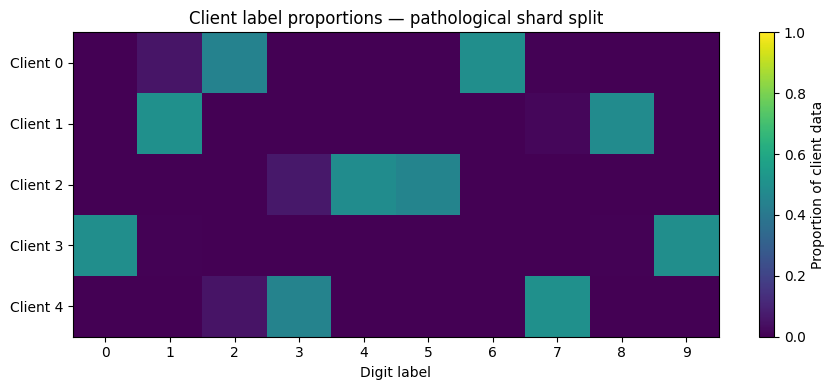

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
image = ax.imshow(proportions.to_numpy(), aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(10))
ax.set_xticklabels(range(10))
ax.set_yticks(range(CFG.num_clients))
ax.set_yticklabels([f"Client {i}" for i in range(CFG.num_clients)])
ax.set_xlabel("Digit label")
ax.set_title("Client label proportions — pathological shard split")
fig.colorbar(image, ax=ax, label="Proportion of client data")
plt.tight_layout()
plt.show()

For seed 42, the validated split is strongly concentrated:

- Client 0: mostly digits 2 and 6
- Client 1: mostly digits 1 and 8
- Client 2: mostly digits 4 and 5
- Client 3: mostly digits 0 and 9
- Client 4: mostly digits 3 and 7

Small counts from neighboring labels are expected because 6,000-example shard boundaries do
not perfectly align with MNIST class counts.

## 5. Load the common initial model

In [18]:
INITIAL_MODEL_PATH = REPO_ROOT / CFG.iid_results_dir / "initial_model.pt"

initial_state = torch.load(INITIAL_MODEL_PATH, map_location="cpu")

model = SimpleMLP(784, 10)
model.load_state_dict(initial_state)
model.to(device)

loss_fn = nn.CrossEntropyLoss()
initial_loss, initial_acc = evaluate(model, test_loader, loss_fn, device)

print(f"Initial loss: {initial_loss:.6f}")
print(f"Initial accuracy: {initial_acc:.4f}")

Initial loss: 2.313339
Initial accuracy: 0.1267


This must match the IID baseline because the data partition should not affect evaluation of
the untouched initial model. The validated value is approximately **loss 2.313339,
accuracy 12.67%**.

## 6. Client-update diagnostic

In [19]:
RUN_CLIENT_DIAGNOSTIC = False

if RUN_CLIENT_DIAGNOSTIC:
    diagnostic_model = SimpleMLP(784, 10)
    diagnostic_model.load_state_dict(copy.deepcopy(initial_state))
    diagnostic_model.to(device)

    global_before = copy.deepcopy(diagnostic_model)

    local_model = client_update(
        diagnostic_model,
        client_loaders[0],
        local_epochs=1,
        learning_rate=CFG.learning_rate,
        loss_fn=loss_fn,
        device=device,
    )

    print("Local movement:", model_distance(diagnostic_model, local_model))
    print("Global changed:", model_distance(global_before, diagnostic_model))
else:
    print("Diagnostic skipped (set RUN_CLIENT_DIAGNOSTIC=True to reproduce).")

Diagnostic skipped (set RUN_CLIENT_DIAGNOSTIC=True to reproduce).


The previously validated diagnostic for Client 0 at \(E=1\) gave:

- local movement \(\|w_{\text{local}}-w_t\|_2 \approx 1.1444\),
- global-model change during `client_update`: \(0.0\).

This confirms that local training changes the copied client model without mutating the server
model.

## 7. Smoke-test the federated pipeline

In [20]:
def run_experiment(local_epochs: int, num_rounds: int, verbose: bool = True):
    set_seed(CFG.seed)

    model = SimpleMLP(784, 10)
    model.load_state_dict(copy.deepcopy(initial_state))
    model.to(device)

    start = time.perf_counter()
    trained_model, history = federated_train(
        global_model=model,
        client_loaders=client_loaders,
        num_rounds=num_rounds,
        local_epochs=local_epochs,
        learning_rate=CFG.learning_rate,
        loss_fn=nn.CrossEntropyLoss(),
        test_loader=test_loader,
        device=device,
        verbose=verbose,
    )
    runtime = time.perf_counter() - start

    return trained_model, history, runtime

In [22]:
RESULT_DIR = REPO_ROOT / "results" / "dirichlet_noniid"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

In [23]:
torch.save(
    dirichlet_indices,
    RESULT_DIR / "client_indices_alpha_0.1.pt",
)

distribution_df.to_csv(
    RESULT_DIR / "client_label_distribution_alpha_0.1.csv",
    index=False,
)

NameError: name 'dirichlet_indices' is not defined

In [21]:
RUN_SMOKE_TEST = True

if RUN_SMOKE_TEST:
    smoke_model, smoke_history, smoke_runtime = run_experiment(
        local_epochs=1,
        num_rounds=2,
    )
    display(smoke_history)
    print(f"Runtime: {smoke_runtime:.1f}s")
else:
    print("Smoke test skipped; the validated results are summarized below.")

Round  1/2 | loss=1.8266 | acc=0.2537
Round  2/2 | loss=1.3848 | acc=0.5063


,round,test_loss,test_accuracy
0,0,2.313339,0.1267
1,1,1.826554,0.2537
2,2,1.384799,0.5063


Runtime: 64.0s


**Validated smoke tests**

Starting from the same \(w_0\):

- \(E=1,\ T=2\): accuracy rose from 12.67% to about 33.01% and then 39.31%.
- \(E=5,\ T=3\): accuracy rose from 12.67% to 39.63%, 43.74%, and 49.64%.

These runs establish that the shard partition, local training, weighted aggregation, and global
evaluation work end-to-end. They are **development checks**, not yet the final comparison.

## 8. Optional full \(E\)-sweep

In [14]:
def run_e_sweep(e_values, num_rounds):
    histories = {}
    runtimes = {}

    for E in e_values:
        print(f"Running E={E}...")
        _, history, runtime = run_experiment(
            local_epochs=E,
            num_rounds=num_rounds,
            verbose=True,
        )
        histories[E] = history
        runtimes[E] = runtime

    return histories, runtimes


RUN_FULL_SWEEP = False

if RUN_FULL_SWEEP:
    shard_histories, shard_runtimes = run_e_sweep(
        e_values=CFG.local_epoch_values,
        num_rounds=CFG.full_num_rounds,
    )
else:
    print("Full shard sweep disabled by default.")

Full shard sweep disabled by default.


## 9. What to compare against the IID baseline

Once the full shard sweep is run and saved, compare IID and shard non-IID under the same:

- initialization,
- \(E\),
- learning rate,
- batch size,
- number of rounds,
- model and test set.

The primary views should be:

1. test accuracy vs communication round;
2. test loss vs communication round;
3. test accuracy vs cumulative local epochs;
4. client-update magnitude and, later, update-direction similarity.

The important question is not simply whether non-IID data lowers accuracy. It is whether
increasing \(E\) changes the trade-off between local computation and client disagreement.

## 10. Next steps

1. Save the validated shard partition and its label-distribution table.
2. Run the controlled \(E\in\{1,5,10\}\) shard experiment when compute is available.
3. Compare the curves directly with the IID baseline.
4. Add a Dirichlet label-skew partition to `src/data.py`.
5. Add quantity skew after the Dirichlet experiment is validated.
6. Only then introduce FedProx under the same controlled partitions.